In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency, pointbiserialr
import os

from sklearn.preprocessing import StandardScaler,StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

import missingno as msno
from sklearn.utils import resample

from sklearn.preprocessing import MinMaxScaler
from scipy.stats import skew
import missingno as msno

## Diabetics Analysis

### Extract the Diabetics patients and equal amount of non Diabetics


HadDiabetes Summary:
            Count  Percentage
DIABETE3                     
1.0        182062       12.65
2.0         13043        0.91
3.0       1216560       84.50
4.0         24465        1.70
NaN          3566        0.25


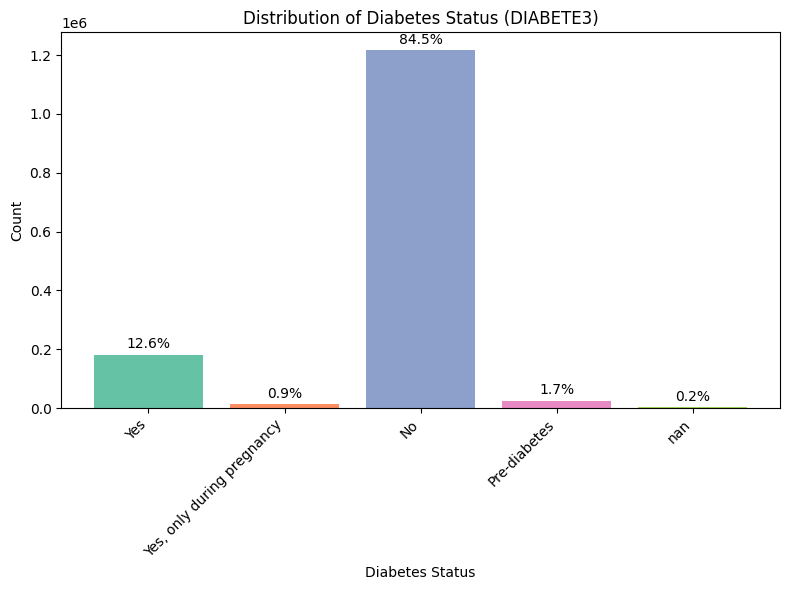

In [2]:
# Create output directory if it doesn't exist

# Load the dataset
df = pd.read_csv('../data/processed/BRFSS_4_Behavioral.csv', low_memory=False)

target = "DIABETE3"

# Check if target exists
if target not in df.columns:
    raise KeyError(f"Target column '{target}' not found in dataset. Available columns: {list(df.columns)}")

# Value counts
value_counts = df[target].value_counts(dropna=False).sort_index()
value_percent = df[target].value_counts(normalize=True, dropna=False).sort_index() * 100

# Combine into summary DataFrame
target_summary = pd.DataFrame({
    "Count": value_counts,
    "Percentage": value_percent.round(2)
})

print("\nHadDiabetes Summary:")
print(target_summary)

# --- BAR PLOT (appropriate for categorical data) ---
plt.figure(figsize=(8, 6))

# Define category labels based on BRFSS coding (adjust if your recoding differs)
labels = {
    1.0: 'Yes',
    2.0: 'Yes, only during pregnancy',
    3.0: 'No',
    4.0: 'Pre-diabetes',
    float('nan'): 'Missing'
}

# Map index to labels
tick_labels = [labels.get(cat, str(cat)) for cat in value_counts.index]

# Plot
bars = plt.bar(tick_labels, value_counts.values, color=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854"])

# Add percentage labels on bars
for bar, pct in zip(bars, value_percent.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(value_counts) * 0.01,
             f'{pct:.1f}%', ha='center', va='bottom')

plt.title("Distribution of Diabetes Status (DIABETE3)")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/had_diabetes_bar.png')
plt.show()


 Binary Diabetes Target (Cleaned: No Nulls, No Pregnancy/Pre-Diabetes)

Counts:
HasDiabetes
0.0    1216560
1.0     182062
Name: count, dtype: int64

Percentages:
HasDiabetes
0.0    86.98
1.0    13.02
Name: proportion, dtype: float64

 Clean dataset saved to: ../data/processed/BRFSS_Diabetes_Binary.csv


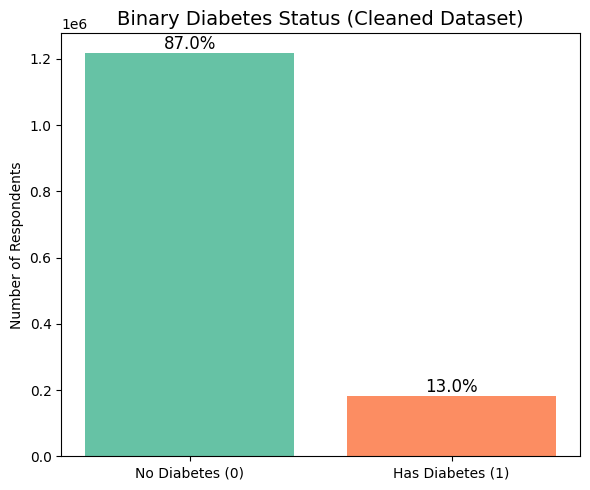

In [3]:
# Define valid diabetes responses for binary classification:
#   1.0 = Yes (has diabetes) → label as 1
#   3.0 = No (does not have diabetes) → label as 0
# Exclude: 2.0 (pregnancy), 4.0 (pre-diabetes), NaN, and any other codes

# Create binary target ONLY for valid cases
df['HasDiabetes'] = df['DIABETE3'].map({1.0: 1, 3.0: 0})

# Keep ONLY rows where HasDiabetes is 0 or 1 (i.e., drop everything else, including NaN)
df_binary = df[df['HasDiabetes'].isin([0, 1])].copy()

# Reset index for cleanliness
df_binary.reset_index(drop=True, inplace=True)

# Summary
print("\n Binary Diabetes Target (Cleaned: No Nulls, No Pregnancy/Pre-Diabetes)")
print("\nCounts:")
print(df_binary['HasDiabetes'].value_counts().sort_index())
print("\nPercentages:")
print((df_binary['HasDiabetes'].value_counts(normalize=True) * 100).round(2))

# Save clean dataset
output_path = '../data/processed/BRFSS_Diabetes_Binary.csv'
df_binary.to_csv(output_path, index=False)
print(f"\n Clean dataset saved to: {output_path}")

# --- Visualization ---
plt.figure(figsize=(6, 5))
counts = df_binary['HasDiabetes'].value_counts().sort_index()
labels = ['No Diabetes (0)', 'Has Diabetes (1)']
colors = ['#66c2a5', '#fc8d62']

bars = plt.bar(labels, counts.values, color=colors)

# Add percentage labels on bars
total = len(df_binary)
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.001,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.title('Binary Diabetes Status (Cleaned Dataset)', fontsize=14)
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.savefig('../results/binary_diabetes_distribution.png', dpi=150)
plt.show()

In [4]:
input_path = '../data/processed/BRFSS_Diabetes_Binary.csv'
df = pd.read_csv(input_path)

print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")

# Check Target Distribution

target = "HasDiabetes"

counts = df[target].value_counts()
proportions = df[target].value_counts(normalize=True) * 100

print("\nCounts:")
print(counts)
print("\nPercentages:")
print(proportions.round(2))

# Split Majority / Minority

df_majority = df[df[target] == 0.0]
df_minority = df[df[target] == 1.0]

print(f"\nMajority class size (0.0): {len(df_majority)}")
print(f"Minority class size (1.0): {len(df_minority)}")

# Downsample Majority

df_majority_downsampled = resample(
    df_majority,
    replace=False,             # no replacement
    n_samples=len(df_minority),# match minority size
    random_state=42
)

# Combine Balanced Dataset

df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"\n Balanced dataset created: {df_balanced.shape[0]} rows")

# Check New Distribution

balanced_counts = df_balanced[target].value_counts()
balanced_proportions = df_balanced[target].value_counts(normalize=True) * 100

print("\nBalanced Counts:")
print(balanced_counts)
print("\nBalanced Percentages:")
print(balanced_proportions.round(2))

# Save Balanced Dataset

output_path = '../data/processed/BRFSS_Diabetes_Balanced.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_balanced.to_csv(output_path, index=False)

print(f"\n Balanced dataset saved to: {output_path}")


Loaded dataset: 1398622 rows, 141 columns

Counts:
HasDiabetes
0.0    1216560
1.0     182062
Name: count, dtype: int64

Percentages:
HasDiabetes
0.0    86.98
1.0    13.02
Name: proportion, dtype: float64

Majority class size (0.0): 1216560
Minority class size (1.0): 182062

 Balanced dataset created: 364124 rows

Balanced Counts:
HasDiabetes
0.0    182062
1.0    182062
Name: count, dtype: int64

Balanced Percentages:
HasDiabetes
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64

 Balanced dataset saved to: ../data/processed/BRFSS_Diabetes_Balanced.csv


### Drop Missing than 80%

In [5]:
df = pd.read_csv('../data/processed/BRFSS_Diabetes_Balanced.csv')

# Check for remaining missing values
missing_pct = df.isnull().mean() * 100
high_missing = missing_pct[missing_pct > 50].index.tolist()
print(f"Features with >50% missing: {high_missing}")

target = 'HasDiabetes'
features = [col for col in df.columns if col != target]

# Auto-detect types
numerical_features = df[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
# But exclude binary flags (0/1) from "numerical" if you want
binary_features = [col for col in numerical_features if sorted(df[col].dropna().unique()) in [[0,1], [0.0,1.0]]]
numerical_features = [col for col in numerical_features if col not in binary_features]

categorical_features = df[features].select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical (non-binary): {len(numerical_features)}")
print(f"Binary: {len(binary_features)}")
print(f"Categorical: {len(categorical_features)}")



Features with >50% missing: ['CADULT', 'BLDSUGAR', 'HOWLONG', 'PDIABTST', 'HADSIGM3', 'RCSRLTN2', 'IMFVPLAC', 'FEETCHK2', 'PREDIAB1', 'MISTMNT', 'QLSTRES2', 'CASTHDX2', 'CASTHNO2', 'SCNTPAID', 'CTELNUM1', 'INSULIN', 'LSTBLDS3', 'CELLFON2', 'PVTRESD2', 'EMTSUPRT', 'PADUR2_', '_CLLCPWT', 'BLDSTOOL', 'CHILDREN', 'DIABEYE', 'FLSHTMY2', 'QLMENTL2', 'LMTJOIN3', 'DIABEDU', 'PREGNANT', '_PNEUMO2', 'JOINPAIN', 'CVDASPRN', 'NUMPHON2', 'EYEEXAM', 'HAREHAB1', 'DIABAGE2', 'DOCTDIAB', 'LANDLINE', 'PAINACT2', 'SCNTWRK1', 'QLHLTH2', 'LSATISFY', 'CHKHEMO3', 'PAFREQ2_', 'RCSGENDR', 'CSTATE', 'STOPSMK2', 'HPVADSHT', 'SCNTLWK1', 'FEETCHK', 'STREHAB1', 'SCNTLPAD', 'HPVADVC2']
Numerical (non-binary): 115
Binary: 21
Categorical: 4


In [6]:

# Load your balanced dataset
df = pd.read_csv('../data/processed/BRFSS_Diabetes_Balanced.csv')

# Step 1: Identify and drop features with >80% missing
missing_pct = df.isnull().mean() * 100
cols_to_drop = missing_pct[missing_pct > 80].index.tolist()
df_clean = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Dropped {len(cols_to_drop)} features with >80% missing.")
print(f"Dataset shape after dropping: {df_clean.shape}")

# Step 2: Handle categorical columns (object dtype)
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns found: {categorical_cols}")

# Try to convert to numeric (BRFSS sometimes stores numbers as strings)
for col in categorical_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Check if any object columns remain
remaining_object = df_clean.select_dtypes(include=['object']).columns.tolist()
if remaining_object:
    print(f"Still object-type columns (will drop): {remaining_object}")
    df_clean = df_clean.drop(columns=remaining_object)

# Step 3: Final missing value check
final_missing = df_clean.isnull().mean() * 100
high_missing_final = final_missing[final_missing > 20].index.tolist()  # Alert if any >20%
if high_missing_final:
    print(f"\n Warning: {len(high_missing_final)} features still have >20% missing:")
    for col in high_missing_final:
        print(f"  {col}: {final_missing[col]:.1f}%")

# Step 4: Save cleaned dataset
output_path = '../data/processed/BRFSS_Diabetes_Cleaned.csv'
df_clean.to_csv(output_path, index=False)
print(f"\n Cleaned dataset saved to: {output_path}")
print(f"Final shape: {df_clean.shape} (rows, columns)")
print(f"Target 'HasDiabetes' distribution:")
print(df_clean['HasDiabetes'].value_counts(normalize=True).round(3))

Dropped 35 features with >80% missing.
Dataset shape after dropping: (364124, 106)

Categorical columns found: ['IMONTH', 'IYEAR', 'IDATE', 'IDAY']

  CADULT: 76.7%
  NUMMEN: 23.3%
  IMFVPLAC: 67.9%
  CTELNUM1: 76.7%
  INSULIN: 78.3%
  CELLFON2: 76.7%
  PVTRESD2: 76.7%
  MSCODE: 24.6%
  PADUR2_: 63.1%
  IMONTH: 100.0%
  CHILDREN: 79.2%
  DIABEYE: 78.6%
  FLSHTMY2: 52.3%
  LMTJOIN3: 60.9%
  DIABEDU: 78.4%
  _PNEUMO2: 63.2%
  JOINPAIN: 67.2%
  IYEAR: 100.0%
  NUMADULT: 23.3%
  PADUR1_: 38.6%
  EYEEXAM: 78.6%
  CPDEMO1: 23.9%
  DIABAGE2: 70.9%
  NUMWOMEN: 23.3%
  LANDLINE: 76.7%
  PAFREQ2_: 62.4%
  CSTATE: 76.7%
  PAFREQ1_: 37.7%
  IDATE: 100.0%
  IDAY: 100.0%
  NUMHHOL2: 23.8%

 Cleaned dataset saved to: ../data/processed/BRFSS_Diabetes_Cleaned.csv
Final shape: (364124, 106) (rows, columns)
Target 'HasDiabetes' distribution:
HasDiabetes
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


### Remove Metadata like Date time, States

In [7]:
# Load CSV file 
df = pd.read_csv('../data/processed/BRFSS_Diabetes_Cleaned.csv')

# Show dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Show feature (column) names
print("\nFeature names (columns):")
print(df.columns.tolist())

# Show first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Show dataset info 
print("\nDataset Info:")
print(df.info())


Number of rows: 364124
Number of columns: 106

Feature names (columns):
['_WT2RAKE', 'FMONTH', 'USEEQUIP', 'CADULT', 'QSTVER', 'DIABETE3', 'NUMMEN', 'IMFVPLAC', 'VETERAN3', 'SEQNO', 'DISPCODE', 'CTELNUM1', 'SEATBELT', 'INSULIN', '_STATE', 'CELLFON2', 'PVTRESD2', 'MSCODE', '_PSU', '_CHLDCNT', 'PADUR2_', 'IMONTH', '_LLCPWT', 'CHILDREN', '_RFSEAT2', 'DIABEYE', 'USENOW3', 'FLSHTMY2', 'LMTJOIN3', 'SEX', 'DIABEDU', '_PNEUMO2', 'JOINPAIN', '_RFHYPE5', '_RAWRAKE', 'FC60_', 'IYEAR', '_MISVEGN', 'MARITAL', '_LTASTH1', 'NUMADULT', 'PADUR1_', '_STSTR', 'EYEEXAM', '_RFSEAT3', 'CPDEMO1', 'DIABAGE2', '_VEGRESP', 'NUMWOMEN', 'CTELENUM', '_STRWT', 'LANDLINE', '_CASTHM1', '_ASTHMS1', '_FRTRESP', 'QSTLANG', '_CHOLCHK', '_DRDXAR1', 'PAFREQ2_', 'CSTATE', 'YEAR', 'MAXVO2_', 'PAFREQ1_', 'IDATE', '_RFHLTH', 'IDAY', 'NUMHHOL2', 'RENTHOM1', 'YEAR.1', 'BMI', 'height_m', 'weight_kg', 'diet_score', 'smoking_status', 'alcohol_level', 'age_score', 'cv_risk_score', 'health_score', 'med_conditions_score', 'care_access

In [11]:
# Load cleaned dataset
df = pd.read_csv('../data/processed/BRFSS_Diabetes_Cleaned.csv')

# Define columns to DROP (metadata, weights, admin, non-clinical)
metadata_cols = [
    # Survey weights & design
    'SEQNO', 'MSCODE', '_STATE', '_PSU', '_STRWT', '_STSTR',
    '_LLCPWT', '_RAWRAKE', '_WT2RAKE', '_CLLCPWT',
    
    # Date/time
    'IDAY', 'IMONTH', 'IDATE', 'IYEAR', 'FMONTH', 'YEAR', 'YEAR.1',
    
    # Interview/admin metadata
    'RCSGENDR', 'CPDEMO1', 'CSTATE', 'CTELENUM', 'CTELNUM1', 'DISPCODE',
    'QSTLANG', 'QSTVER', 'LANDLINE', 'CELLFON2', 'PVTRESD2', '_RFSEAT3', '_RFSEAT2',
    
    # Household composition (not individual health)
    'NUMADULT', 'NUMHHOL2', 'NUMMEN', 'NUMWOMEN', 'CADULT',
    
    # Other non-clinical
    'VETERAN3', 'MARITAL', 'RENTHOM1', 'SEATBELT', 'USEEQUIP', 'USENOW3',
    'CASTHDX2', 'CVDASPRN', 'IMFVPLAC', 'RCSRLTN2', '_CHLDCNT',
    'MAXVO2_', 'FC60_', 

    # Add any other known non-medical columns here
    '_VEGRESP', '_FRTRESP'

]

# Only keep columns that exist in your dataset
cols_to_drop = [col for col in metadata_cols if col in df.columns]
print(f"Found {len(cols_to_drop)} metadata/admin columns to drop.")

# Drop them
df_medical = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Shape after dropping metadata: {df_medical.shape}")

# Optional: Also drop any remaining columns with >50% missing (aggressive but safe)
missing_pct = df_medical.isnull().mean() * 100
high_missing = missing_pct[missing_pct > 50].index.tolist()
if high_missing:
    print(f"Dropping {len(high_missing)} more columns with >50% missing...")
    df_medical = df_medical.drop(columns=high_missing)

# Final check
print(f"\n Final dataset shape: {df_medical.shape}")
print(f"Columns remaining: {df_medical.shape[1]}")

# Save
output_path = '../data/processed/BRFSS_Diabetes_MedicalOnly.csv'
df_medical.to_csv(output_path, index=False)
print(f"\n Medical-only dataset saved to: {output_path}")

Found 45 metadata/admin columns to drop.
Shape after dropping metadata: (364124, 61)
Dropping 12 more columns with >50% missing...

 Final dataset shape: (364124, 49)
Columns remaining: 49

 Medical-only dataset saved to: ../data/processed/BRFSS_Diabetes_MedicalOnly.csv


In [12]:
# Show dataset dimensions
print("Number of rows:", df_medical.shape[0])
print("Number of columns:", df_medical.shape[1])

# Show feature (column) names
print("\nFeature names (columns):")
print(df_medical.columns.tolist())

# Show first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df_medical.head())

# Show dataset info 
print("\nDataset Info:")
print(df_medical.info())


Number of rows: 364124
Number of columns: 49

Feature names (columns):
['DIABETE3', 'SEX', '_RFHYPE5', '_MISVEGN', '_LTASTH1', 'PADUR1_', '_CASTHM1', '_ASTHMS1', '_CHOLCHK', '_DRDXAR1', 'PAFREQ1_', '_RFHLTH', 'BMI', 'height_m', 'weight_kg', 'diet_score', 'smoking_status', 'alcohol_level', 'age_score', 'cv_risk_score', 'health_score', 'med_conditions_score', 'care_access_score', 'has_arthritis', 'arthritis_limits_activity', 'arthritis_manages_weight', 'arthritis_exercises', 'current_asthma', 'asthma_attack_past_year', 'uses_inhaler', 'current_smoker', 'never_smoked', 'had_mammogram', 'had_pap_test', 'had_colon_screening', 'ever_hiv_tested', 'meets_aerobic_guidelines', 'strength_freq_weekly', 'meets_strength_guidelines', 'any_physical_activity', 'income_score', 'edu_score', 'low_ses_flag', 'ARTHDIS2_missing', 'ASTHNOW_missing', 'HADMAM_missing', 'HADPAP2_missing', 'HADSGCO1_missing', 'HasDiabetes']

First 5 rows of the dataset:
   DIABETE3  SEX  _RFHYPE5      _MISVEGN  _LTASTH1  PADUR1_ 